In [5]:
import numpy as np
rng = np.random.default_rng()

# Mean estimation

Here we are estimating a mean. Let us start from defining the RV whose expected value we want to estimate.

- $\omega_t \sim P$
- $\mu = E_P[\omega_t]$ 

We are going to run the experiment for $T$ steps, and plot three different estimates:

1. The empirical mean $\mu_t = 1/t \sum_{i=1}^t \omega_i$.
This can be calculated recursively as 
$\mu_t = \mu_{t-1} \frac{t-1}{t} + \omega_t \frac{1}{t} = \mu_{t-1} + (\omega_t - \mu_{t-1}) \frac{1}{t}$.

2. The parameter updated with the exact gradient (which assumes you know $\mu$, and so is not implementable in practice).

3. The parameter updated with the noisy gradient:
$\mu_t = \mu_{t-1} + \alpha_t (\omega_t - \mu_{t-1})$.

Note that the empirical mean udpate is the same as the noisy gradient update if $\alpha_t = 1/t$.

Let us check all these in practice:


In [21]:
# First, we try with fixed alpha:
mu = 0.5
T = 100
empirical_mean = np.zeros(T)
oracle_mean = np.zeros(T)
gradient_mean = np.zeros(T)

for t in range(1,T):
    alpha = 0.1
    omega = rng.normal(mu)
    empirical_mean[t] = empirical_mean[t-1] + (omega - empirical_mean[t-1])/t
    oracle_mean[t] = oracle_mean[t-1] + (mu - oracle_mean[t-1]) * alpha
    gradient_mean[t] = gradient_mean[t-1] + (omega - gradient_mean[t-1]) * alpha
        

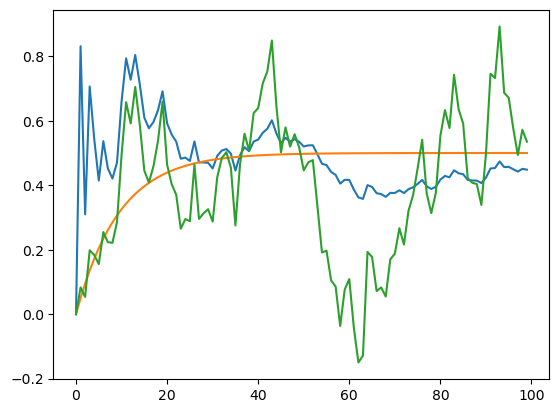

In [25]:
import matplotlib.pyplot as plt
plt.plot(empirical_mean)
plt.plot(oracle_mean)
plt.plot(gradient_mean)

In [28]:
# Now, we try with alpha=1/t:
mu = 0.5
T = 100
empirical_mean = np.zeros(T)
oracle_mean = np.zeros(T)
gradient_mean = np.zeros(T)

for t in range(1,T):
    alpha = 1/t
    omega = rng.normal(mu)
    empirical_mean[t] = empirical_mean[t-1] + (omega - empirical_mean[t-1])/t
    oracle_mean[t] = oracle_mean[t-1] + (mu - oracle_mean[t-1]) * alpha
    gradient_mean[t] = gradient_mean[t-1] + (omega - gradient_mean[t-1]) * alpha
        

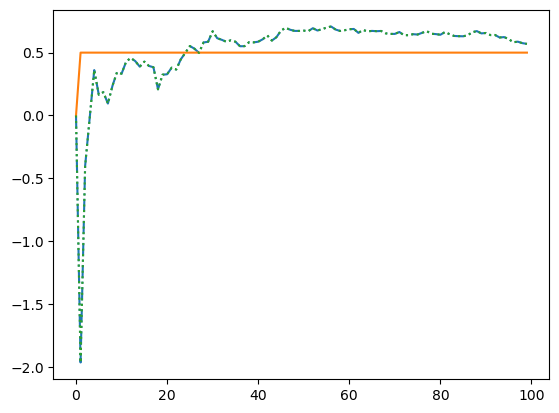

In [33]:
plt.plot(empirical_mean, '-.')
plt.plot(oracle_mean)
plt.plot(gradient_mean, ':')

In [36]:
# Now, we try with alpha=2/(2+t):
mu = 0.5
T = 100
empirical_mean = np.zeros(T)
oracle_mean = np.zeros(T)
gradient_mean = np.zeros(T)

for t in range(1,T):
    alpha = 1/(2+t)
    omega = rng.normal(mu)
    empirical_mean[t] = empirical_mean[t-1] + (omega - empirical_mean[t-1])/t
    oracle_mean[t] = oracle_mean[t-1] + (mu - oracle_mean[t-1]) * alpha
    gradient_mean[t] = gradient_mean[t-1] + (omega - gradient_mean[t-1]) * alpha
        

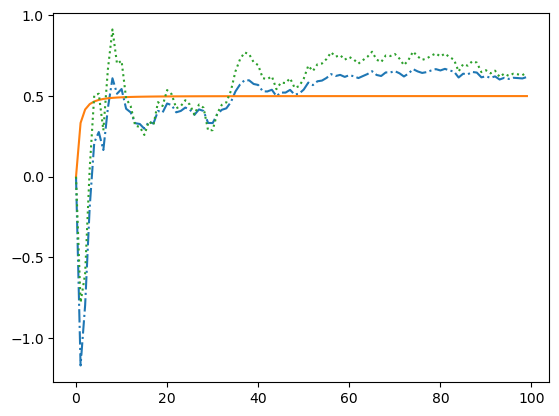

In [35]:
plt.plot(empirical_mean, '-.')
plt.plot(oracle_mean)
plt.plot(gradient_mean, ':')